

Test each pipeline step independently 

## 1. Imports & Load Config

In [16]:
import sys
from pathlib import Path
import openeo
import xarray as xr
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

# Load the unified Hydra config WITHOUT @hydra.main (notebook-friendly)
PACKAGE_ROOT = Path(r"c:\Git_projects\openeo_mountains_snow\src\openeo_mountains_snow")
sys.path.insert(0, str(PACKAGE_ROOT.parent))

from openeo_mountains_snow.spatial_extent_utils import resolve_aoi, bbox_to_geometry

base_cfg = OmegaConf.load(PACKAGE_ROOT / "conf" / "config.yaml")
exp_cfg = OmegaConf.load(PACKAGE_ROOT / "conf" / "experiment" / "reconstruction.yaml")

# Merge experiment into the base config under "experiment" key
cfg = OmegaConf.merge(base_cfg, {"experiment": exp_cfg})
print(OmegaConf.to_yaml(cfg))

connection:
  endpoint: openeo.dataspace.copernicus.eu
sentinel2_l2a:
  collection: SENTINEL2_L2A
  scl_band: SCL
  cloud_values:
  - 8
  - 9
  - 3
  - 10
sentinel2_l1c:
  collection: SENTINEL2_L1C
  bands:
  - B02
  - B03
  - B04
  - B08
  - B11
  - sunZenithAngles
  - sunAzimuthAngles
water_mask:
  collection: ESA_WORLDCOVER_10M_2021_V2
  band: MAP
  water_values:
  - 80
modis:
  stac_url: https://stac.eurac.edu/collections/MOD10A1v61
agera5:
  stac_url: https://stac.openeo.vito.be/collections/agera5_daily
  bands:
  - 2m_temperature_mean
  - dewpoint_temperature_mean
  - solar_radiation_flux
  band_aliases:
  - temperature-mean
  - dewpoint-temperature
  - solar-radiation-flux
geopotential:
  stac_url: https://stac.openeo.vito.be/collections/geopotential
dem:
  slope_stac_url: https://stac.openeo.vito.be/collections/DEM_slope_30m
  aspect_stac_url: https://stac.openeo.vito.be/collections/DEM_aspec_30m
processing:
  crs: 32632
  resolution: 20.0
  cloud_prob: 80
  pixel_ratio: 25
  i

## 2. Connect to openEO

In [17]:
eoconn = openeo.connect(cfg.connection.endpoint).authenticate_oidc()

Authenticated using refresh token.


## 3. Define a TINY test extent

Use a much smaller spatial/temporal extent than the real experiment so each `.execute()` completes in seconds, not hours. Override the config values here.

In [18]:
# ---- Test extent (≈10km x 10km, 5 days) ----
# Plain bbox dict — the standard format everywhere
# NOTE: MODIS STAC (Eurac) covers only the Senales catchment:
#   x: [632050, 655550], y: [5167950, 5183950] (EPSG:32632)
#   time: 2016-01-01 to 2023-02-01
spatial_extent = {
    "west": 635000.0,
    "south": 5170000.0,
    "east": 645000.0,   # 10 km
    "north": 5180000.0, # 10 km
    "crs": "EPSG:32632",
}
temporal_extent = ["2023-01-10", "2023-01-15"]  # within MODIS range (ends 2023-02-01)

# For MODIS / AGERA steps later
modis_temporal_extent = ["2023-01-10", "2023-01-15"]
agera_temporal_extent = ["2023-01-10", "2023-01-15"]

proc = cfg.processing
recon = cfg.reconstruction
print(f"Test bbox: {spatial_extent}")
print(f"Test period: {temporal_extent}")

Test bbox: {'west': 635000.0, 'south': 5170000.0, 'east': 645000.0, 'north': 5180000.0, 'crs': 'EPSG:32632'}
Test period: ['2023-01-10', '2023-01-15']


## 4. Test: Load raw Sentinel-2 data

Simplest possible test — can we load S2 data and download it?

In [19]:
# Load raw SCL band — this is the simplest data load in the pipeline
scl = eoconn.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=spatial_extent,
    temporal_extent=temporal_extent,
    bands=["SCL"],
    max_cloud_cover=proc.cloud_prob,
)

scl

## 5. Test: Snow Cover Fraction (spectral indices + representative pixels)

This is the improved SCF from `snow_cover_fraction.py` — the whole point of the integration. Download and visualize.

<xarray.Dataset> Size: 42kB
Dimensions:  (t: 1, x: 100, y: 100)
Coordinates:
  * t        (t) datetime64[ns] 8B 2023-06-02
  * x        (x) float64 800B 6.318e+05 6.318e+05 ... 6.328e+05 6.328e+05
  * y        (y) float64 800B 5.174e+06 5.174e+06 ... 5.173e+06 5.173e+06
Data variables:
    crs      |S1 1B ...
    snow     (t, y, x) float32 40kB ...
Attributes:
    Conventions:  CF-1.9
    institution:  openEO platform


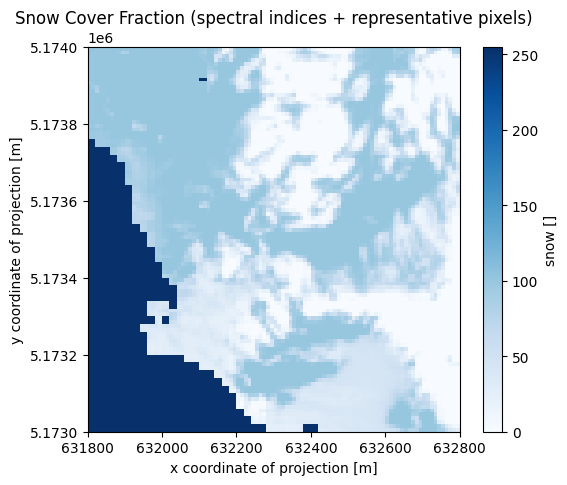

In [6]:
from openeo_mountains_snow.snow_cover_fraction import snow_cover_fraction_cube

snow = snow_cover_fraction_cube(
    spatial_extent=spatial_extent,
    time_period=temporal_extent,
    c=eoconn,
    cfg=cfg,
).rename_labels(dimension="bands", target=["snow"])

# Download as NetCDF and inspect
snow.download("test_snow.nc")
ds = xr.open_dataset("test_snow.nc")
print(ds)

# Plot first timestep
ds["snow"].isel(t=0).plot(figsize=(6, 5), cmap="Blues")
plt.title("Snow Cover Fraction (spectral indices + representative pixels)")
plt.show()

## 7. Test: SCF Masks & Conditional Probabilities

Test `compute_scf_masks` — this combines the simple snow mask with MODIS SCF to produce conditional probability inputs.

In [6]:
from openeo_mountains_snow.snowcoverarea_reconstruction.scf_processing import compute_scf_masks

all_masks, labels_scf = compute_scf_masks(eoconn, cfg, spatial_extent, temporal_extent)
print(f"✅ SCF mask labels: {labels_scf}")

# Download to verify — use job_options from config for higher memory
job_options = OmegaConf.to_container(cfg.experiment.job_options, resolve=True)
all_masks.execute_batch("test_scf_masks.nc", job_options=job_options)
ds_masks = xr.open_dataset("test_scf_masks.nc")
print(ds_masks)

Using 'eo:bands' metadata, but STAC extension eo was not declared.


Using 'eo:bands' metadata, but STAC extension eo was not declared.


✅ SCF mask labels: ['scf_0_10', 'scf_10_20', 'scf_20_30', 'scf_30_40', 'scf_40_50', 'scf_50_60', 'scf_60_70', 'scf_70_80', 'scf_80_90', 'scf_90_100']
0:00:00 Job 'j-2604231113154cfd93fdb91e818fd3ab': send 'start'
0:00:24 Job 'j-2604231113154cfd93fdb91e818fd3ab': created (progress 0%)
0:00:29 Job 'j-2604231113154cfd93fdb91e818fd3ab': created (progress 0%)
0:00:36 Job 'j-2604231113154cfd93fdb91e818fd3ab': created (progress 0%)
0:00:44 Job 'j-2604231113154cfd93fdb91e818fd3ab': created (progress 0%)
0:00:54 Job 'j-2604231113154cfd93fdb91e818fd3ab': created (progress 0%)
0:01:07 Job 'j-2604231113154cfd93fdb91e818fd3ab': queued (progress 0%)
0:01:22 Job 'j-2604231113154cfd93fdb91e818fd3ab': queued (progress 0%)
0:01:43 Job 'j-2604231113154cfd93fdb91e818fd3ab': queued (progress 0%)
0:02:09 Job 'j-2604231113154cfd93fdb91e818fd3ab': running (progress N/A)
0:02:41 Job 'j-2604231113154cfd93fdb91e818fd3ab': running (progress N/A)
0:03:21 Job 'j-2604231113154cfd93fdb91e818fd3ab': running (progress 

## 8. Test: Downscale Temperature & Humidity

Test climate downscaling independently. This loads AGERA5, DEM, and geopotential.

Deriving band listing from unordered `item_assets`
Using 'eo:bands' metadata, but STAC extension eo was not declared.
Deriving band listing from unordered `item_assets`


0:00:00 Job 'j-260428112513491999837d63a2840416': send 'start'
0:00:18 Job 'j-260428112513491999837d63a2840416': created (progress 0%)
0:00:23 Job 'j-260428112513491999837d63a2840416': created (progress 0%)
0:00:29 Job 'j-260428112513491999837d63a2840416': created (progress 0%)
0:00:37 Job 'j-260428112513491999837d63a2840416': created (progress 0%)
0:00:47 Job 'j-260428112513491999837d63a2840416': created (progress 0%)
0:01:00 Job 'j-260428112513491999837d63a2840416': created (progress 0%)
0:01:15 Job 'j-260428112513491999837d63a2840416': running (progress N/A)
0:01:34 Job 'j-260428112513491999837d63a2840416': running (progress N/A)
0:01:59 Job 'j-260428112513491999837d63a2840416': running (progress N/A)
0:02:29 Job 'j-260428112513491999837d63a2840416': finished (progress 100%)
<xarray.Dataset> Size: 313B
Dimensions:               (t: 5, x: 2, y: 2)
Coordinates:
  * t                     (t) datetime64[ns] 40B 2023-01-10 ... 2023-01-14
  * x                     (x) float64 16B 10.8 10.

IndexError: index 2 is out of bounds for axis 0 with size 2

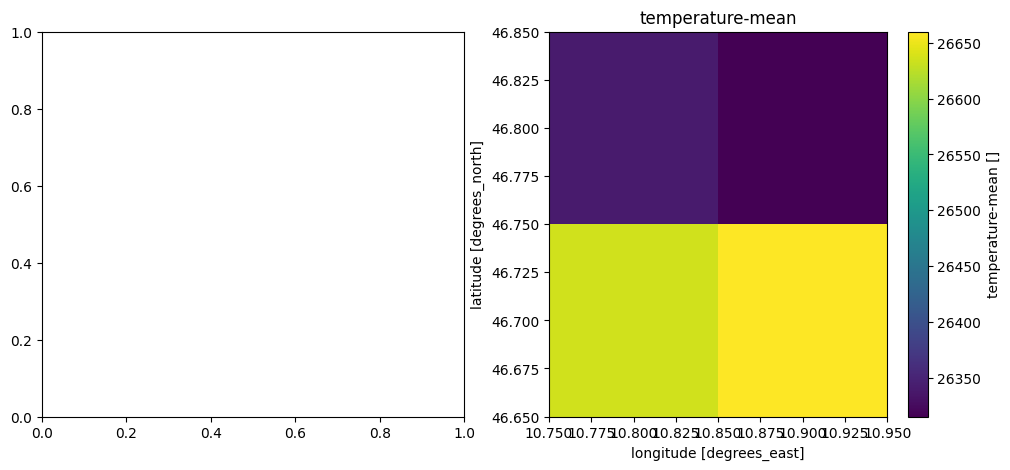

In [6]:
from openeo_mountains_snow.snowcoverarea_reconstruction.downscale_variables import (
    downscale_temperature_humidity, downscale_shortwave_radiation,
)
job_options = OmegaConf.to_container(cfg.experiment.job_options, resolve=True)

# Use a fixed date for time dimension
first_date = temporal_extent[0]

# DEM
dem = eoconn.load_collection("COPERNICUS_30", spatial_extent=spatial_extent)
if dem.metadata.has_temporal_dimension():
    dem = dem.reduce_dimension(dimension="t", reducer="max")
dem = dem.add_dimension(name="t", label=first_date, type="temporal")

# AGERA5
agera = eoconn.load_stac(
    cfg.agera5.stac_url,
    spatial_extent=spatial_extent,
    temporal_extent=agera_temporal_extent,
)
agera = agera.filter_bands(bands=list(cfg.agera5.bands))
agera = agera.rename_labels(dimension="bands", target=list(cfg.agera5.band_aliases))

# Geopotential — single global STAC Feature: load_stac can't filter it,
# so we load the full item then crop with filter_bbox server-side.
geopotential = eoconn.load_stac(
    cfg.geopotential.stac_url,
    spatial_extent=spatial_extent,
    bands=["geopotential"],
)


#TODO fix issue with geopotential
agera_downscaled =agera
#agera_downscaled = downscale_temperature_humidity(agera, dem, geopotential.max_time())

agera_downscaled.execute_batch("test_agera_downscaled.nc", job_options=job_options)
ds_agera = xr.open_dataset("test_agera_downscaled.nc")

print(ds_agera)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, var in enumerate(ds_agera.data_vars):
    if ds_agera[var].dims == ("t", "y", "x"):
        ds_agera[var].isel(t=0).plot(ax=axes[i])
        axes[i].set_title(var)
plt.tight_layout()
plt.show()

## 9. Test: Downscale Shortwave Radiation

In [14]:
import importlib
from openeo_mountains_snow.snowcoverarea_reconstruction import downscale_variables
importlib.reload(downscale_variables)
from openeo_mountains_snow.snowcoverarea_reconstruction.downscale_variables import (
    downscale_shortwave_radiation,
)

aspect = eoconn.load_stac(
    cfg.dem.aspect_stac_url, spatial_extent=spatial_extent
).reduce_dimension(dimension="t", reducer="mean")

slope = eoconn.load_stac(
    cfg.dem.slope_stac_url, spatial_extent=spatial_extent
).reduce_dimension(dimension="t", reducer="mean")

slope_aspect = aspect.merge_cubes(slope).rename_labels(
    dimension="bands", target=["aspect", "slope"]
)

shortwave_rad_cube = downscale_shortwave_radiation(agera, slope_aspect)

# UDFs declare `pvlib` via PEP 723 inline metadata, which is only honored by
# batch jobs (not synchronous .download()), so use execute_batch here.
shortwave_rad_cube.execute_batch("test_shortwave.nc", job_options=job_options)
ds_sw = xr.open_dataset("test_shortwave.nc")
print(ds_sw)
    

Deriving band listing from unordered `item_assets`
Using 'eo:bands' metadata, but STAC extension eo was not declared.
Deriving band listing from unordered `item_assets`
Using 'eo:bands' metadata, but STAC extension eo was not declared.


0:00:00 Job 'j-2604281143264553ac768051666e201d': send 'start'
0:00:18 Job 'j-2604281143264553ac768051666e201d': created (progress 0%)
0:00:23 Job 'j-2604281143264553ac768051666e201d': created (progress 0%)
0:00:36 Job 'j-2604281143264553ac768051666e201d': created (progress 0%)
0:00:44 Job 'j-2604281143264553ac768051666e201d': created (progress 0%)
0:00:54 Job 'j-2604281143264553ac768051666e201d': queued (progress 0%)
0:01:06 Job 'j-2604281143264553ac768051666e201d': queued (progress 0%)
0:01:22 Job 'j-2604281143264553ac768051666e201d': queued (progress 0%)
0:01:41 Job 'j-2604281143264553ac768051666e201d': queued (progress 0%)
0:02:16 Job 'j-2604281143264553ac768051666e201d': running (progress N/A)
0:02:46 Job 'j-2604281143264553ac768051666e201d': running (progress N/A)
0:03:23 Job 'j-2604281143264553ac768051666e201d': running (progress N/A)
0:04:10 Job 'j-2604281143264553ac768051666e201d': running (progress N/A)
0:05:09 Job 'j-2604281143264553ac768051666e201d': running (progress N/A)


## 10. Chain it all together

Once each step above works individually, chain them and run the full pipeline on the tiny extent.

In [23]:
# If all steps above passed, run the full pipeline on the tiny test extent
import importlib
from openeo_mountains_snow.snowcoverarea_reconstruction import pipeline as _pipeline
importlib.reload(_pipeline)
from openeo_mountains_snow.snowcoverarea_reconstruction.pipeline import run_reconstruction

# Override the experiment config to use our tiny test extent
test_cfg = OmegaConf.merge(cfg, {
    "experiment": {
        "aoi": spatial_extent,
        "temporal_extent": temporal_extent,
        "modis_temporal_extent": modis_temporal_extent,
        "agera_temporal_extent": agera_temporal_extent,
        "title_prefix": "test_baby_steps",
    }
})

run_reconstruction(test_cfg, eoconn, spatial_extent)
#print("🎉 Uncomment the line above when ready to run the full pipeline.")


Using 'eo:bands' metadata, but STAC extension eo was not declared.
Using 'eo:bands' metadata, but STAC extension eo was not declared.
Deriving band listing from unordered `item_assets`
Using 'eo:bands' metadata, but STAC extension eo was not declared.
Deriving band listing from unordered `item_assets`
Deriving band listing from unordered `item_assets`
Using 'eo:bands' metadata, but STAC extension eo was not declared.
Deriving band listing from unordered `item_assets`
Using 'eo:bands' metadata, but STAC extension eo was not declared.


0:00:00 Job 'j-26042813330743c0959ed662f5eaf39a': send 'start'
0:00:22 Job 'j-26042813330743c0959ed662f5eaf39a': created (progress 0%)
0:00:27 Job 'j-26042813330743c0959ed662f5eaf39a': created (progress 0%)
0:00:34 Job 'j-26042813330743c0959ed662f5eaf39a': created (progress 0%)
0:00:42 Job 'j-26042813330743c0959ed662f5eaf39a': created (progress 0%)
0:00:52 Job 'j-26042813330743c0959ed662f5eaf39a': created (progress 0%)
0:01:05 Job 'j-26042813330743c0959ed662f5eaf39a': running (progress N/A)
0:01:21 Job 'j-26042813330743c0959ed662f5eaf39a': running (progress N/A)
0:01:40 Job 'j-26042813330743c0959ed662f5eaf39a': running (progress N/A)
0:02:05 Job 'j-26042813330743c0959ed662f5eaf39a': running (progress N/A)
0:02:35 Job 'j-26042813330743c0959ed662f5eaf39a': running (progress N/A)
0:03:13 Job 'j-26042813330743c0959ed662f5eaf39a': running (progress N/A)
0:04:00 Job 'j-26042813330743c0959ed662f5eaf39a': running (progress N/A)
0:04:58 Job 'j-26042813330743c0959ed662f5eaf39a': running (progres

JobFailedException: Batch job 'j-26042813330743c0959ed662f5eaf39a' didn't finish successfully. Status: error (after 0:25:17).

In [25]:
import importlib
from openeo_mountains_snow.snowcoverarea_reconstruction import (
    downscale_variables,
    pipeline as _pipeline,
)

# Ensure the notebook uses the latest on-disk implementations.
importlib.reload(downscale_variables)
importlib.reload(_pipeline)
from openeo_mountains_snow.snowcoverarea_reconstruction.pipeline import run_reconstruction

exp = cfg.experiment

test_cfg = OmegaConf.merge(cfg, {
    "experiment": {
        "aoi": spatial_extent,
        "temporal_extent": list(exp.temporal_extent),
        "modis_temporal_extent": list(exp.modis_temporal_extent),
        "agera_temporal_extent": list(exp.agera_temporal_extent),
        "title_prefix": exp.title_prefix or "swe",
        "job_options": exp.job_options,
    }
})

run_reconstruction(test_cfg, eoconn, spatial_extent)


Using 'eo:bands' metadata, but STAC extension eo was not declared.
Using 'eo:bands' metadata, but STAC extension eo was not declared.
Deriving band listing from unordered `item_assets`
Using 'eo:bands' metadata, but STAC extension eo was not declared.
Deriving band listing from unordered `item_assets`
Deriving band listing from unordered `item_assets`
Using 'eo:bands' metadata, but STAC extension eo was not declared.
Deriving band listing from unordered `item_assets`
Using 'eo:bands' metadata, but STAC extension eo was not declared.


0:00:00 Job 'j-26042906440547438e35f745accaa453': send 'start'
0:00:28 Job 'j-26042906440547438e35f745accaa453': created (progress 0%)
0:00:33 Job 'j-26042906440547438e35f745accaa453': created (progress 0%)
0:00:39 Job 'j-26042906440547438e35f745accaa453': created (progress 0%)
0:00:48 Job 'j-26042906440547438e35f745accaa453': created (progress 0%)
0:00:58 Job 'j-26042906440547438e35f745accaa453': created (progress 0%)
0:01:10 Job 'j-26042906440547438e35f745accaa453': created (progress 0%)
0:01:26 Job 'j-26042906440547438e35f745accaa453': queued (progress 0%)
0:01:47 Job 'j-26042906440547438e35f745accaa453': queued (progress 0%)
0:02:11 Job 'j-26042906440547438e35f745accaa453': queued (progress 0%)
0:02:41 Job 'j-26042906440547438e35f745accaa453': queued (progress 0%)
0:03:19 Job 'j-26042906440547438e35f745accaa453': running (progress N/A)
0:04:06 Job 'j-26042906440547438e35f745accaa453': running (progress N/A)
0:05:09 Job 'j-26042906440547438e35f745accaa453': running (progress N/A)
0:

JobFailedException: Batch job 'j-26042906440547438e35f745accaa453' didn't finish successfully. Status: canceled (after 4:28:08).